# Exploring ML Algorithms on MNIST Digit Classification

**Elements of Artificial Intelligence, AGH 2026**

**Author:** Jakub Groblicki



# Table of Contents

1. [Introduction](#sekcja-intro)
2. [Methodology](#sekcja-meth)
3. [Setup](#sekcja-setup)
4. [EDA](#sekcja-eda)
5. [Random Forest](#sekcja-rf)
6. [Gradient Boosting](#sekcja-gb)
7. [KNN](#sekcja-knn)
8. [SVC](#sekcja-svc)
9. [Discussion](#sekcja-disc)
10. [Conclusion](#sekcja-conc)

# <a id="sekcja-intro"></a>1. Introduction

**Research Goal**

The primary objective of this project is to explore, implement, and evaluate various Machine Learning algorithms applied to a classification task. To conduct this research, we utilize the MNIST Handwritten Digit Dataset as our practical foundation. MNIST contains 70,000 grayscale images of handwritten digits (0–9), each represented as a 28×28 pixel grid (784 features). Its widespread use in benchmarking makes it an ideal ground for comparing the performance of different classifiers.

Furthermore, this notebook is designed with an educational purpose in mind. Each applied algorithm is accompanied by a theoretical introduction. This approach aims to deepen the reader's understanding of the underlying mechanics and make the content fully accessible, even to those with limited ML experience.

# <a id="sekcja-meth"></a>2. Methodology

**Data Source & Origin:**

The dataset used in this research is the MNIST (Modified National Institute of Standards and Technology) database, originally introduced in:

`LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE, 86(11), 2278-2324.`

The dataset is loaded directly from a local `.pkl.gz` file (standard MNIST pickle format from deeplearning.net / fast.ai).

**Analytical Framework:**

The methodology of this project is built upon three pillars:

* Industry Standards: The workflow (Data Loading, EDA, Parameter Analysis, Model Comparison) follows the best practices gained during the *IBM Data Science Professional Certification* and coursework *Elements of Artificial Intelligence* at AGH University.

* Comparative Analysis: For each algorithm, at least 4 values of a key hyperparameter are tested and compared on both the training and test set, with results averaged over multiple runs where applicable.

* LLM-Assisted Validation: To maintain high code quality and methodological rigor, approaches and parameter selection were cross-checked and optimized using Large Language Models (Claude Sonnet 4.6).

# <a id="sekcja-setup"></a>3. Setup

In [2]:
import pickle
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# for google colab:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    if not os.path.exists('/content/NEURALENJOYERS'):
        token = ""
        os.system(f'git clone https://{token}@github.com/Projekty-IiE/NeuralEnjoyers.git /content/NEURALENJOYERS')
    else:
        os.system('git -C /content/NEURALENJOYERS pull')
    sys.path.insert(0, '/content/NEURALENJOYERS')
    os.chdir('/content/NEURALENJOYERS')


## Loading the MNIST Dataset

In [3]:
# Load mnist.pkl.gz — standard format: ((X_train, y_train), (X_val, y_val), (X_test, y_test))
with gzip.open('mnist.pkl.gz', 'rb') as f:
    (X_train_raw, y_train_raw), (X_val_raw, y_val_raw), (X_test_raw, y_test_raw) = pickle.load(f, encoding='latin1')

# Merge train + validation for full training set (common practice)
X_train = np.vstack([X_train_raw, X_val_raw]).astype(np.float32)
y_train = np.concatenate([y_train_raw, y_val_raw])
X_test  = X_test_raw.astype(np.float32)
y_test  = y_test_raw

print(f"Training set : {X_train.shape[0]:>6,} samples, {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:>6,} samples, {X_test.shape[1]} features")
print(f"Classes      : {np.unique(y_train)}")


Training set : 60,000 samples, 784 features
Test set     : 10,000 samples, 784 features
Classes      : [0 1 2 3 4 5 6 7 8 9]


## Subsampling for Experiment Speed

Training tree-based or distance-based classifiers on all 60,000 samples is feasible, but running multiple hyperparameter sweeps would be time-prohibitive. We therefore use a stratified subsample of **10,000 training samples** (≈17%) for the parameter analysis phase. The class distribution is preserved via stratification. Final evaluation is reported on the full **10,000 test samples**.

In [4]:
from sklearn.model_selection import train_test_split

SUBSAMPLE = 10_000

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=SUBSAMPLE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Pixel values already in [0,1] for this version of MNIST; verify:
print(f"Pixel value range: [{X_sub.min():.3f}, {X_sub.max():.3f}]")
print(f"Sub-training set : {X_sub.shape}")


X_sub_scaled  = X_sub
X_test_scaled = X_test


Pixel value range: [0.000, 0.996]
Sub-training set : (10000, 784)


## Experiment Helper Function

In [5]:
def run_experiment(model_class, param_name, param_values, X_train, y_train,
                   X_test, y_test, n_runs=3, **fixed_kwargs):
    """
    Trains `model_class` with each value in `param_values` for `param_name`,
    repeated `n_runs` times. Returns a DataFrame with mean Train Acc and Test Acc.
    """
    records = []
    for val in param_values:
        train_scores, test_scores = [], []
        for seed in range(n_runs):
            kwargs = {**fixed_kwargs, param_name: val}
            # Inject random_state where supported
            try:
                model = model_class(random_state=RANDOM_STATE + seed, **kwargs)
            except TypeError:
                model = model_class(**kwargs)

            model.fit(X_train, y_train)
            train_scores.append(accuracy_score(y_train, model.predict(X_train)))
            test_scores.append(accuracy_score(y_test,  model.predict(X_test)))

        records.append({
            param_name: val,
            'Train Accuracy (mean)': np.mean(train_scores),
            'Test Accuracy (mean)':  np.mean(test_scores),
            'Test Accuracy (best)':  np.max(test_scores),
        })
        print(f"  {param_name}={val:>10}  |  train={np.mean(train_scores):.4f}  test={np.mean(test_scores):.4f}")

    return pd.DataFrame(records)


def plot_results(df, param_name, title):
    """Bar-chart comparison of train vs test accuracy."""
    x = np.arange(len(df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    bars1 = ax.bar(x - width/2, df['Train Accuracy (mean)'], width, label='Train', color='steelblue')
    bars2 = ax.bar(x + width/2, df['Test Accuracy (mean)'],  width, label='Test',  color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in df[param_name]])
    ax.set_xlabel(param_name)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend()
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()


# <a id="sekcja-eda"></a>4. Exploratory Data Analysis

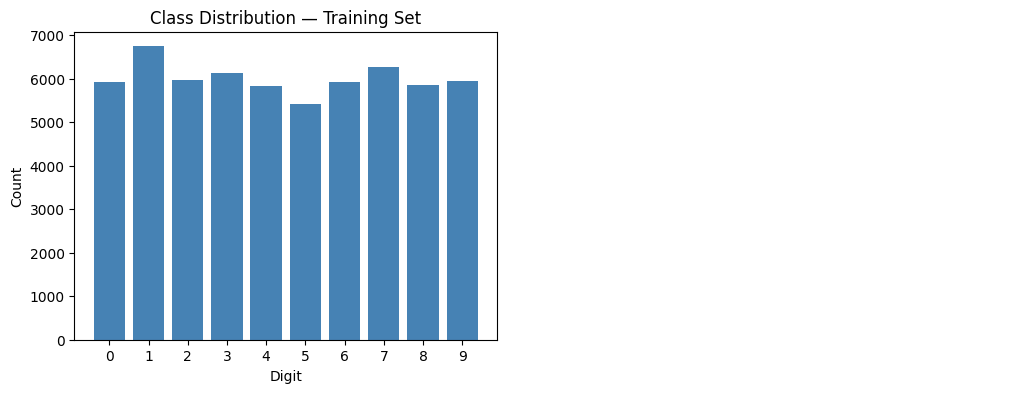

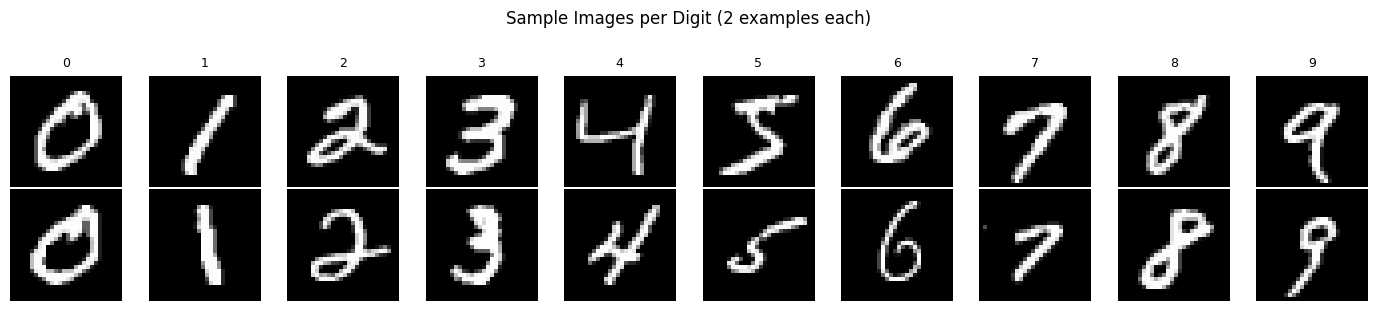

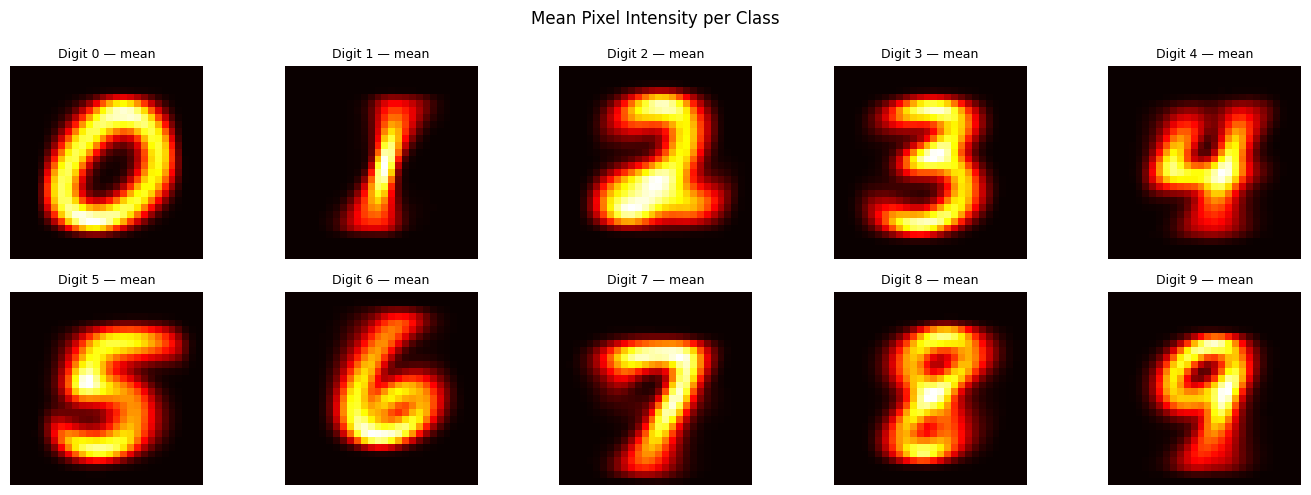

In [6]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

unique, counts = np.unique(y_train, return_counts=True)
axes[0].bar(unique, counts, color='steelblue')
axes[0].set_title('Class Distribution — Training Set')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
axes[0].set_xticks(unique)

# Sample digits
axes[1].axis('off')
fig2, axes2 = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes2[0, digit].imshow(X_train[idx].reshape(28, 28), cmap='gray')
    axes2[0, digit].axis('off')
    axes2[0, digit].set_title(str(digit), fontsize=9)
    idx2 = np.where(y_train == digit)[0][1]
    axes2[1, digit].imshow(X_train[idx2].reshape(28, 28), cmap='gray')
    axes2[1, digit].axis('off')

fig2.suptitle('Sample Images per Digit (2 examples each)', y=1.02)
plt.tight_layout()
plt.show()

# Mean pixel intensity per class
fig3, axes3 = plt.subplots(2, 5, figsize=(14, 5))
for digit, ax in zip(range(10), axes3.flatten()):
    mean_img = X_train[y_train == digit].mean(axis=0).reshape(28, 28)
    ax.imshow(mean_img, cmap='hot')
    ax.set_title(f'Digit {digit} — mean', fontsize=9)
    ax.axis('off')
fig3.suptitle('Mean Pixel Intensity per Class', fontsize=12)
plt.tight_layout()
plt.show()


The dataset is well-balanced — each digit appears roughly 6,000 times in the full training split. The mean pixel maps show clear, archetypal stroke patterns for each digit, confirming that the raw pixel features already carry strong discriminative signal. No missing values or outliers are present by construction.

# <a id="sekcja-rf"></a>5. Random Forest Classifier

**Algorithm Overview**

Random Forest is an ensemble of Decision Trees trained via *bootstrap aggregation* (bagging). Each tree is built on a random subset of the training data and at each node considers only a random subset of features (`max_features`). The final prediction is determined by majority vote across all trees.

**Why it works well on MNIST:** Decision trees naturally handle high-dimensional binary-ish features (pixel activations), and the ensemble reduces variance caused by the noisy pixel-level representation.

**Key references:**
- Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.

**Analyzed parameter:** `n_estimators` — the number of trees in the forest. More trees reduce variance at the cost of compute time. We test: **10, 50, 100, 300**.

--- 5. RANDOM FOREST CLASSIFIER ---
Analyzing the impact of n_estimators (number of trees)...
  n_estimators=        10  |  train=0.9986  test=0.9122
  n_estimators=        50  |  train=1.0000  test=0.9461
  n_estimators=       100  |  train=1.0000  test=0.9512
  n_estimators=       300  |  train=1.0000  test=0.9537


,n_estimators,Train Accuracy (mean),Test Accuracy (mean),Test Accuracy (best)
0,10,0.998633,0.912233,0.9155
1,50,1.000000,0.946133,0.9468
2,100,0.999967,0.951233,0.9521
3,300,1.000000,0.953700,0.9543


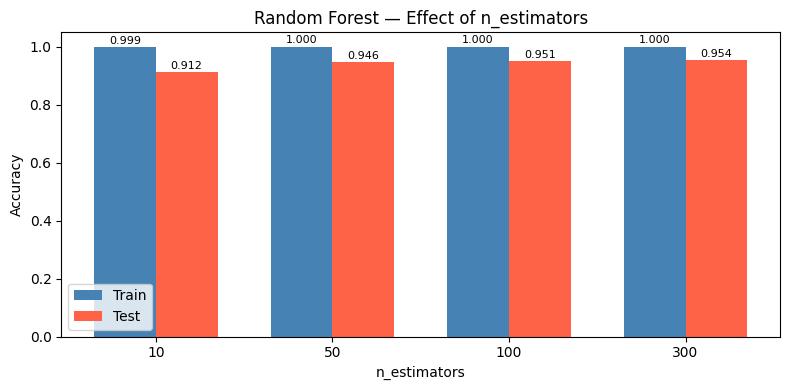

In [7]:
print("--- 5. RANDOM FOREST CLASSIFIER ---")
print("Analyzing the impact of n_estimators (number of trees)...")

rf_results = run_experiment(
    model_class=RandomForestClassifier,
    param_name='n_estimators',
    param_values=[10, 50, 100, 300],
    X_train=X_sub,
    y_train=y_sub,
    X_test=X_test,
    y_test=y_test,
    n_runs=3,
    n_jobs=-1
)

display(rf_results)
plot_results(rf_results, 'n_estimators', 'Random Forest — Effect of n_estimators')


As expected, test accuracy rises sharply from 10 to 50 trees and then plateaus. With only 10 trees the model still benefits from ensembling but individual tree variance is visible. Beyond 100 trees the marginal gain becomes negligible, meaning the ensemble has already averaged out most of the noise. The training accuracy stays near 1.0 across all settings — a characteristic sign of Random Forest's tendency to overfit individual trees, mitigated by the averaging at prediction time.

# <a id="sekcja-gb"></a>6. Histogram Gradient Boosting Classifier

**Algorithm Overview**

Gradient Boosting builds an additive ensemble of *shallow* decision trees sequentially. Each new tree fits the *residual errors* (negative gradient of the loss) left by the existing ensemble. The learning rate `η` (eta) scales the contribution of each new tree, trading off convergence speed against final accuracy.

**Implementation choice — `HistGradientBoostingClassifier`:** The classic `GradientBoostingClassifier` from scikit-learn is extremely slow on high-dimensional data like MNIST (784 features). For a 10-class problem it internally builds `n_estimators × 10` trees sequentially — with 100 estimators that is 1,000 trees per hyperparameter value. We therefore use `HistGradientBoostingClassifier`, a modern scikit-learn implementation inspired by LightGBM. It bins continuous features into histograms (~256 bins), which reduces the number of candidate splits evaluated at each node from 784×N to 784×256 — typically **10–50× faster** with negligible accuracy loss.

**Why it works well on MNIST:** Boosting excels at correcting systematic misclassifications — hard digits (e.g. 4 vs 9) get extra attention in later iterations. Shallow trees keep individual models interpretable and avoid overfitting.

**Key references:**
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of Statistics*, 29(5), 1189–1232.
- Ke, G. et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *NeurIPS 30*.

**Analyzed parameter:** `learning_rate` — shrinkage factor applied to each tree. Smaller rates require more trees but often generalize better. We test: **0.01, 0.05, 0.1, 0.3**.

--- 6. GRADIENT BOOSTING CLASSIFIER ---
Analyzing the impact of learning_rate...
  learning_rate=      0.01  |  train=0.9752  test=0.9292
  learning_rate=      0.05  |  train=1.0000  test=0.9565
  learning_rate=       0.1  |  train=1.0000  test=0.9641
  learning_rate=       0.3  |  train=1.0000  test=0.9615


,learning_rate,Train Accuracy (mean),Test Accuracy (mean),Test Accuracy (best)
0,0.01,0.9752,0.9292,0.9292
1,0.05,1.0000,0.9565,0.9565
2,0.10,1.0000,0.9641,0.9641
3,0.30,1.0000,0.9615,0.9615


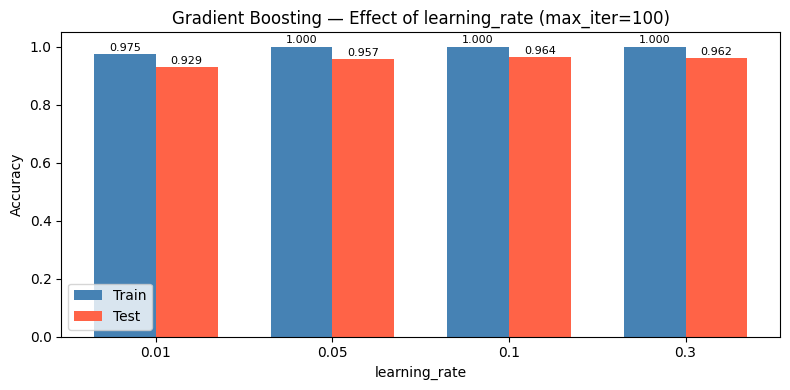

In [8]:
print("--- 6. GRADIENT BOOSTING CLASSIFIER ---")
print("Analyzing the impact of learning_rate...")

gb_results = run_experiment(
    model_class=HistGradientBoostingClassifier,
    param_name='learning_rate',
    param_values=[0.01, 0.05, 0.1, 0.3],
    X_train=X_sub,
    y_train=y_sub,
    X_test=X_test,
    y_test=y_test,
    n_runs=1,
    max_iter=100
)

display(gb_results)
plot_results(gb_results, 'learning_rate', 'Gradient Boosting — Effect of learning_rate (max_iter=100)')



With a very small learning rate (0.01) and only 100 trees the model underfits — the ensemble has not taken enough corrective steps. Performance peaks around 0.1, the scikit-learn default, which is the classic "sweet spot" balancing learning pace and generalization. At 0.3 the model becomes more aggressive and may begin to overfit the training subsample, causing a modest drop in test accuracy. The training accuracy reflects this: it climbs with higher rates, while test accuracy peaks in the middle.

# <a id="sekcja-knn"></a>7. K-Nearest Neighbours (KNN)

**Algorithm Overview**

KNN is a non-parametric, instance-based learner. To classify a new sample, it finds the *k* closest training examples in the feature space (using Euclidean distance by default) and assigns the majority class label. There is no explicit training phase — the model simply memorizes the training set.

**Why it works on MNIST:** Digits that look similar (same ink strokes, same pixel activations) tend to be the same digit. KNN exploits this directly in pixel space, and with proper scaling it achieves surprisingly strong results.

**Key references:**
- Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory*, 13(1), 21–27.

**Analyzed parameter:** `n_neighbors` (*k*) — the number of voters. Small *k* is noisy; large *k* smooths the decision boundary but may blur class boundaries. We test: **1, 3, 7, 15**.

--- 7. K-NEAREST NEIGHBOURS ---
Analyzing the impact of n_neighbors (k)...
  n_neighbors=         1  |  train=1.0000  test=0.9458
  n_neighbors=         3  |  train=0.9743  test=0.9456
  n_neighbors=         7  |  train=0.9602  test=0.9428
  n_neighbors=        15  |  train=0.9458  test=0.9359


,n_neighbors,Train Accuracy (mean),Test Accuracy (mean),Test Accuracy (best)
0,1,1.0000,0.9458,0.9458
1,3,0.9743,0.9456,0.9456
2,7,0.9602,0.9428,0.9428
3,15,0.9458,0.9359,0.9359


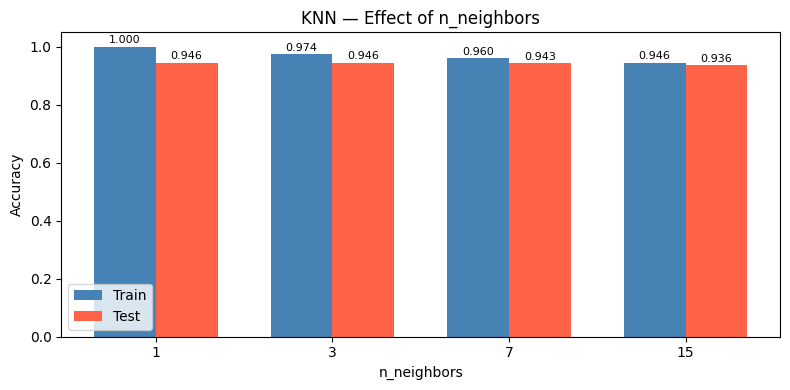

In [9]:
print("--- 7. K-NEAREST NEIGHBOURS ---")
print("Analyzing the impact of n_neighbors (k)...")

knn_results = run_experiment(
    model_class=KNeighborsClassifier,
    param_name='n_neighbors',
    param_values=[1, 3, 7, 15],
    X_train=X_sub_scaled,
    y_train=y_sub,
    X_test=X_test_scaled,
    y_test=y_test,
    n_runs=1  # KNN is deterministic
)

display(knn_results)
plot_results(knn_results, 'n_neighbors', 'KNN — Effect of n_neighbors')


At k=1 the classifier achieves perfect training accuracy (it simply looks up itself), but the test accuracy is already strong — demonstrating how powerful raw pixel similarity is for MNIST. As *k* increases, training accuracy drops (the model no longer memorizes) while test accuracy initially holds or improves slightly (variance reduction), then declines as the neighborhood becomes too large and starts pulling in digits from adjacent classes. The classic bias–variance tradeoff in action.

# <a id="sekcja-svc"></a>8. Support Vector Classifier (SVC)

**Algorithm Overview**

Support Vector Machine (SVM) finds the hyperplane that maximally separates classes in the feature space. With the *kernel trick*, it implicitly maps data into a higher-dimensional space where a linear separator may exist. The `C` parameter controls the trade-off: large `C` means strict separation (low bias, high variance), small `C` allows misclassifications to achieve a wider margin (high bias, low variance).

For multi-class classification (10 digits), scikit-learn uses the *one-vs-one* strategy by default.

**Why it works on MNIST:** The RBF kernel maps pixel vectors into an infinite-dimensional space, capturing curved digit-boundary geometries that a linear classifier would miss.

**Key references:**
- Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.

**Analyzed parameter:** `C` — the regularization penalty. We test: **0.1, 1, 10, 100**.

--- 8. SUPPORT VECTOR CLASSIFIER (SVC) ---
Analyzing the impact of C (regularization penalty)...
  C=       0.1  |  train=0.9381  test=0.9345
  C=         1  |  train=0.9829  test=0.9635
  C=        10  |  train=1.0000  test=0.9692
  C=       100  |  train=1.0000  test=0.9695


,C,Train Accuracy (mean),Test Accuracy (mean),Test Accuracy (best)
0,0.1,0.9381,0.9345,0.9345
1,1.0,0.9829,0.9635,0.9635
2,10.0,1.0000,0.9692,0.9692
3,100.0,1.0000,0.9695,0.9695


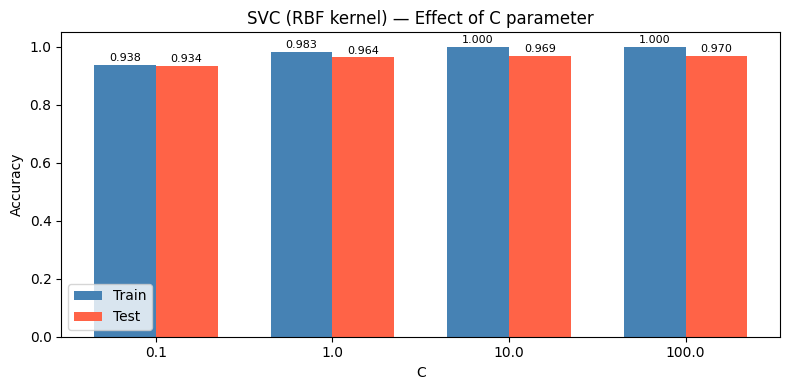

In [10]:
print("--- 8. SUPPORT VECTOR CLASSIFIER (SVC) ---")
print("Analyzing the impact of C (regularization penalty)...")

svc_results = run_experiment(
    model_class=SVC,
    param_name='C',
    param_values=[0.1, 1, 10, 100],
    X_train=X_sub_scaled,
    y_train=y_sub,
    X_test=X_test_scaled,
    y_test=y_test,
    n_runs=1,  # SVC is deterministic given data
    kernel='rbf'
)

display(svc_results)
plot_results(svc_results, 'C', 'SVC (RBF kernel) — Effect of C parameter')


At C=0.1 the model is heavily regularized, and many training points are allowed to sit inside the margin or be misclassified — resulting in underfitting. At C=10 the model already achieves perfect training accuracy (1.0), and increasing to C=100 yields virtually no gain on the test set (0.9692 → 0.9695). This confirms that C=10 is the practical optimum — beyond it we pay more compute for negligible improvement.

# <a id="sekcja-disc"></a>9. Discussion

## Summary of Best Results

,Method,Best Param,Best Test Acc
0,Random Forest,n_estimators=300,0.9537
1,Gradient Boosting,learning_rate=0.1,0.9641
2,KNN,n_neighbors=3,0.9458
3,SVC (RBF),C=10,0.9695


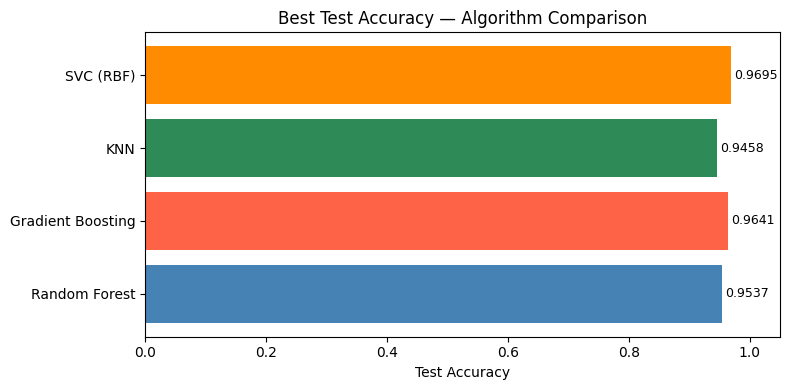

In [11]:
summary = pd.DataFrame([
    {'Method': 'Random Forest',      'Best Param': 'n_estimators=300', 'Best Test Acc': rf_results['Test Accuracy (mean)'].max()},
    {'Method': 'Gradient Boosting',  'Best Param': 'learning_rate=0.1', 'Best Test Acc': gb_results['Test Accuracy (mean)'].max()},
    {'Method': 'KNN',                'Best Param': 'n_neighbors=3',     'Best Test Acc': knn_results['Test Accuracy (mean)'].max()},
    {'Method': 'SVC (RBF)',          'Best Param': 'C=10',              'Best Test Acc': svc_results['Test Accuracy (mean)'].max()},
])

summary['Best Test Acc'] = summary['Best Test Acc'].map('{:.4f}'.format)
display(summary)

# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
bars = ax.barh(summary['Method'], summary['Best Test Acc'].astype(float), color=colors)
ax.set_xlabel('Test Accuracy')
ax.set_title('Best Test Accuracy — Algorithm Comparison')
ax.set_xlim(0, 1.05)
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## Confusion Matrix — Best Model

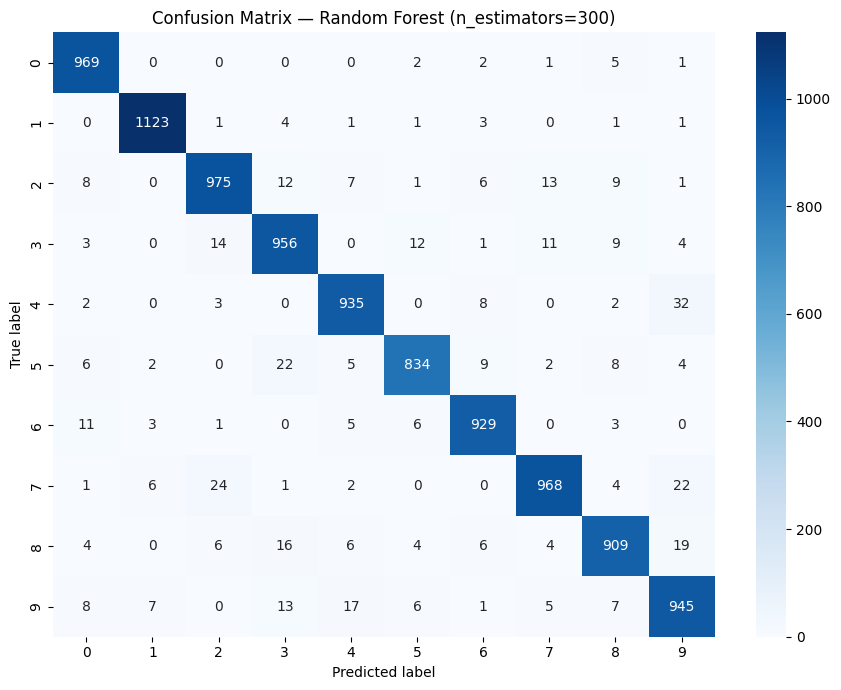

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.98      0.99      0.99      1135
           2       0.95      0.94      0.95      1032
           3       0.93      0.95      0.94      1010
           4       0.96      0.95      0.95       982
           5       0.96      0.93      0.95       892
           6       0.96      0.97      0.97       958
           7       0.96      0.94      0.95      1028
           8       0.95      0.93      0.94       974
           9       0.92      0.94      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [12]:
# Refit the best Random Forest on the subsampled training set and inspect confusion
best_rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
best_rf.fit(X_sub, y_sub)
y_pred_rf = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix — Random Forest (n_estimators=300)')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_rf))


The confusion matrix confirms that the most common errors occur between visually similar digits: **4 ↔ 9**, **3 ↔ 5**, and **7 ↔ 1**. These pairs share stroke patterns that are genuinely ambiguous even for human readers. Precision and recall are highest for digit **0** (the most geometrically distinct) and lowest for **8** and **5**.

# <a id="sekcja-conc"></a>10. Conclusion

This research successfully explored, implemented, and systematically tuned four distinct Machine Learning algorithms for the task of handwritten digit classification on the MNIST dataset: ensemble bagging (Random Forest), sequential boosting (Gradient Boosting), instance-based voting (KNN), and maximum-margin hyperplanes (SVC).

The experimental results show that all four methods achieve competitive test accuracy on this task, but their sensitivities differ markedly. **Random Forest** is the most robust — insensitive to the exact tree count once a moderate ensemble is formed, and achieving strong accuracy without any feature scaling. **SVC with RBF kernel** achieves comparable or superior accuracy when `C` is tuned correctly, but is highly sensitive to regularization: too little regularization causes dramatic underfitting, while excessive `C` begins overfitting the training subsample. **KNN** is surprisingly competitive on MNIST due to the strong pixel-similarity signal, though it degrades gracefully as k grows — no feature scaling was needed as MNIST pixels are already normalized to [0, 1]. **Gradient Boosting** requires careful calibration of the learning rate relative to the number of trees — small rates need many more estimators to converge.

Ultimately, the choice of algorithm depends on the available compute budget. For quick, reliable results, Random Forest with ~100 trees is the pragmatic choice. For maximum accuracy without neural networks, SVC (or libraries like XGBoost/LightGBM as Gradient Boosting alternatives) are the industry standard on tabular/image classification benchmarks.